# 03 — Modeling: XGBoost RUL Predictor
### AV Fleet Predictive Maintenance | NASA CMAPS FD001

**Business question:** Can we predict how many operational cycles each vehicle has left before failure — with enough accuracy to schedule proactive maintenance and avoid $2,400 unplanned breakdowns?

This notebook trains an XGBoost regression model to predict Remaining Useful Life (RUL). The primary output isn't a number — it's a **binary alert**: flag any vehicle predicted to fail within 7 cycles so the dispatch team can route it to maintenance during a low-demand window.

**Input:** `data/processed/train_processed.csv`, `data/processed/test_processed.csv`  
**Output:** `models/xgboost_rul_model.json`, three saved figures

---
## Section 1 — Setup and Data Loading

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
shap.initjs()

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")
FIGURES_DIR   = Path("../reports/figures")

for d in [MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Business constants ────────────────────────────────────────────────────────
# These drive the threshold optimization in Section 7.
# A missed failure costs 6× more than an unnecessary maintenance event.
COST_FALSE_NEGATIVE = 2400   # unplanned breakdown: lost revenue + emergency repair
COST_FALSE_POSITIVE = 400    # unnecessary scheduled maintenance
ALERT_WINDOW        = 7      # cycles — vehicles within this window need maintenance

print("Setup complete.")

Setup complete.


In [2]:
# ── Load processed datasets ───────────────────────────────────────────────────
df_train = pd.read_csv(PROCESSED_DIR / "train_processed.csv")
df_test  = pd.read_csv(PROCESSED_DIR / "test_processed.csv")

# ── Define feature and target columns ────────────────────────────────────────
# Features: the 22 rolling sensor statistics produced in notebook 02.
# We exclude unit_id and time_in_cycles — they are identifiers, not signals.
# We exclude the target column itself (rul_capped).
TARGET       = "rul_capped"
EXCLUDE_COLS = {"unit_id", "time_in_cycles", "rul_capped", "rul_true"}
FEATURE_COLS = [c for c in df_train.columns if c not in EXCLUDE_COLS]

print(f"Target column : {TARGET}")
print(f"Feature count : {len(FEATURE_COLS)}")
print(f"Features      : {FEATURE_COLS}")
print()
print(f"Train shape   : {df_train.shape}")
print(f"Test shape    : {df_test.shape}")

Target column : rul_capped
Feature count : 22
Features      : ['rolling_mean_sensor_2', 'rolling_std_sensor_2', 'rolling_mean_sensor_3', 'rolling_std_sensor_3', 'rolling_mean_sensor_4', 'rolling_std_sensor_4', 'rolling_mean_sensor_7', 'rolling_std_sensor_7', 'rolling_mean_sensor_9', 'rolling_std_sensor_9', 'rolling_mean_sensor_11', 'rolling_std_sensor_11', 'rolling_mean_sensor_12', 'rolling_std_sensor_12', 'rolling_mean_sensor_14', 'rolling_std_sensor_14', 'rolling_mean_sensor_17', 'rolling_std_sensor_17', 'rolling_mean_sensor_20', 'rolling_std_sensor_20', 'rolling_mean_sensor_21', 'rolling_std_sensor_21']

Train shape   : (20631, 25)
Test shape    : (13096, 25)


---
## Section 2 — Train / Validation Split

We split by **vehicle ID**, not by row. This is non-negotiable for time-series data.

If we split by row, the model could see a vehicle's readings from cycle 200 during training, then be asked to "predict" that same vehicle's reading at cycle 50 during validation. It would essentially have memorized the answer. That's data leakage — the model looks great on paper but fails in deployment because real predictions are always about the *future*, not the past.

Splitting by vehicle ID means every vehicle appears entirely in either training or validation — never both.

In [3]:
# ── 80/20 unit split ──────────────────────────────────────────────────────────
# Sort unit IDs and assign the first 80% to training, the remaining 20% to
# validation. Using a deterministic sort (not random) keeps results reproducible
# without needing a random seed for the split itself.
all_units  = sorted(df_train["unit_id"].unique())
n_train    = int(len(all_units) * 0.80)

train_units = all_units[:n_train]
val_units   = all_units[n_train:]

df_tr  = df_train[df_train["unit_id"].isin(train_units)].reset_index(drop=True)
df_val = df_train[df_train["unit_id"].isin(val_units)].reset_index(drop=True)

X_tr   = df_tr[FEATURE_COLS]
y_tr   = df_tr[TARGET]
X_val  = df_val[FEATURE_COLS]
y_val  = df_val[TARGET]

print(f"Training   : {len(train_units)} vehicles, {len(df_tr):,} rows")
print(f"Validation : {len(val_units)} vehicles, {len(df_val):,} rows")
print(f"\nTrain vehicles : {train_units}")
print(f"Val vehicles   : {val_units}")

Training   : 80 vehicles, 16,138 rows
Validation : 20 vehicles, 4,493 rows

Train vehicles : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.in

---
## Section 3 — Baseline Model (Mean Predictor)

Before building anything complex, we establish a dumb baseline: predict the mean RUL of the training set for *every single observation*.

This is equivalent to a fleet manager saying "our vehicles fail at an average of X cycles, so I'll assume every vehicle has X cycles left." It ignores individual vehicle data entirely. Any model worth deploying must beat this convincingly — otherwise we're spending engineering effort to build something that offers no improvement over a single number written on a sticky note.

In [4]:
# ── Mean predictor ────────────────────────────────────────────────────────────
mean_rul_train   = y_tr.mean()
y_baseline       = np.full(len(y_val), fill_value=mean_rul_train)

baseline_rmse = np.sqrt(mean_squared_error(y_val, y_baseline))
baseline_mae  = mean_absolute_error(y_val, y_baseline)

print(f"Mean RUL predicted for every observation: {mean_rul_train:.1f} cycles")
print()
print(f"Baseline RMSE : {baseline_rmse:.2f} cycles")
print(f"Baseline MAE  : {baseline_mae:.2f} cycles")
print()
print("Interpretation: on average, the mean predictor is off by the MAE above.")
print("A vehicle with 3 cycles left gets the same prediction as one with 120.")
print("This is useless for individual scheduling — our model must do better.")

Mean RUL predicted for every observation: 86.0 cycles

Baseline RMSE : 41.47 cycles
Baseline MAE  : 37.26 cycles

Interpretation: on average, the mean predictor is off by the MAE above.
A vehicle with 3 cycles left gets the same prediction as one with 120.
This is useless for individual scheduling — our model must do better.


---
## Section 4 — XGBoost Model

XGBoost (Extreme Gradient Boosting) builds an ensemble of decision trees, where each tree corrects the errors of the previous one. It consistently performs well on tabular sensor data and is the industry standard for CMAPS-style predictive maintenance benchmarks.

**Note on hyperparameters:** The parameters below are reasonable starting values from the CMAPS literature and general XGBoost best practices. In a production context, we would run a grid search or Bayesian optimization over hundreds of parameter combinations to squeeze out additional performance. For this portfolio project, we demonstrate the modeling *framework* — the infrastructure for tuning is in place and could be added with a few lines of code.

In [5]:
# ── Train XGBoost regressor ───────────────────────────────────────────────────
# n_estimators=200   : build 200 trees — enough to capture the degradation
#                      pattern without overfitting on 80 training vehicles
# max_depth=6        : trees can ask up to 6 nested questions — deep enough
#                      for complex sensor interactions, not so deep it memorizes
# learning_rate=0.05 : small steps = more trees needed, but better generalization
# subsample=0.8      : each tree sees 80% of training rows (reduces overfitting)
# colsample_bytree=0.8: each tree sees 80% of features (similar benefit)
model = XGBRegressor(
    n_estimators      = 200,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    verbosity         = 0,
)

model.fit(X_tr, y_tr)
print("Model trained.")

Model trained.


In [6]:
# ── Evaluate on validation set ────────────────────────────────────────────────
y_pred_val = model.predict(X_val)

xgb_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
xgb_mae  = mean_absolute_error(y_val, y_pred_val)
xgb_r2   = r2_score(y_val, y_pred_val)
rmse_improvement_pct = 100 * (baseline_rmse - xgb_rmse) / baseline_rmse

print("── Validation Results ──────────────────────────────────────────")
print(f"  Baseline RMSE  : {baseline_rmse:.2f} cycles  (mean predictor)")
print(f"  XGBoost RMSE   : {xgb_rmse:.2f} cycles  ({rmse_improvement_pct:.1f}% improvement over baseline)")
print(f"  XGBoost MAE    : {xgb_mae:.2f} cycles")
print(f"  XGBoost R²     : {xgb_r2:.4f}")
print("──────────────────────────────────────────────────────────────")
print()
print("R² interpretation: a value of 1.0 means perfect prediction;")
print("0.0 means no better than predicting the mean (our baseline).")
print(f"At R²={xgb_r2:.2f}, the model explains {xgb_r2*100:.0f}% of the variance")
print("in remaining useful life — a meaningful improvement for maintenance scheduling.")

── Validation Results ──────────────────────────────────────────
  Baseline RMSE  : 41.47 cycles  (mean predictor)
  XGBoost RMSE   : 19.30 cycles  (53.5% improvement over baseline)
  XGBoost MAE    : 14.22 cycles
  XGBoost R²     : 0.7815
──────────────────────────────────────────────────────────────

R² interpretation: a value of 1.0 means perfect prediction;
0.0 means no better than predicting the mean (our baseline).
At R²=0.78, the model explains 78% of the variance
in remaining useful life — a meaningful improvement for maintenance scheduling.


---
## Section 5 — SHAP Explainability

SHAP (SHapley Additive exPlanations) tells us *why* the model made each prediction. For each feature and each observation, it calculates how much that feature pushed the prediction higher or lower.

This matters for fleet operations for two reasons:
1. **Operator trust** — a maintenance team won't act on a model they don't understand. Being able to say "we're flagging Vehicle 47 because its turbine temperature trend (sensor_11) has been rising for 5 cycles" is far more convincing than "the model said so."
2. **Sensor investment** — if 80% of predictive power comes from 3 sensors, the engineering team knows which channels to prioritize for calibration and redundancy.

In [7]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
# TreeExplainer is optimized for tree-based models (XGBoost, LightGBM, etc.).
# It runs much faster than the generic KernelExplainer for large datasets.
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

# Mean absolute SHAP value per feature — how much does each feature
# move the prediction on average across all validation observations?
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS,
).sort_values(ascending=False)

print("Top 10 features by mean |SHAP| value:")
print(mean_abs_shap.head(10).round(4).to_string())

Top 10 features by mean |SHAP| value:
rolling_mean_sensor_4     10.2469
rolling_mean_sensor_11     6.4352
rolling_mean_sensor_9      5.1915
rolling_mean_sensor_14     2.8977
rolling_mean_sensor_21     2.7462
rolling_mean_sensor_3      2.7459
rolling_mean_sensor_2      2.4629
rolling_mean_sensor_17     1.7059
rolling_mean_sensor_7      1.6275
rolling_mean_sensor_20     1.5235


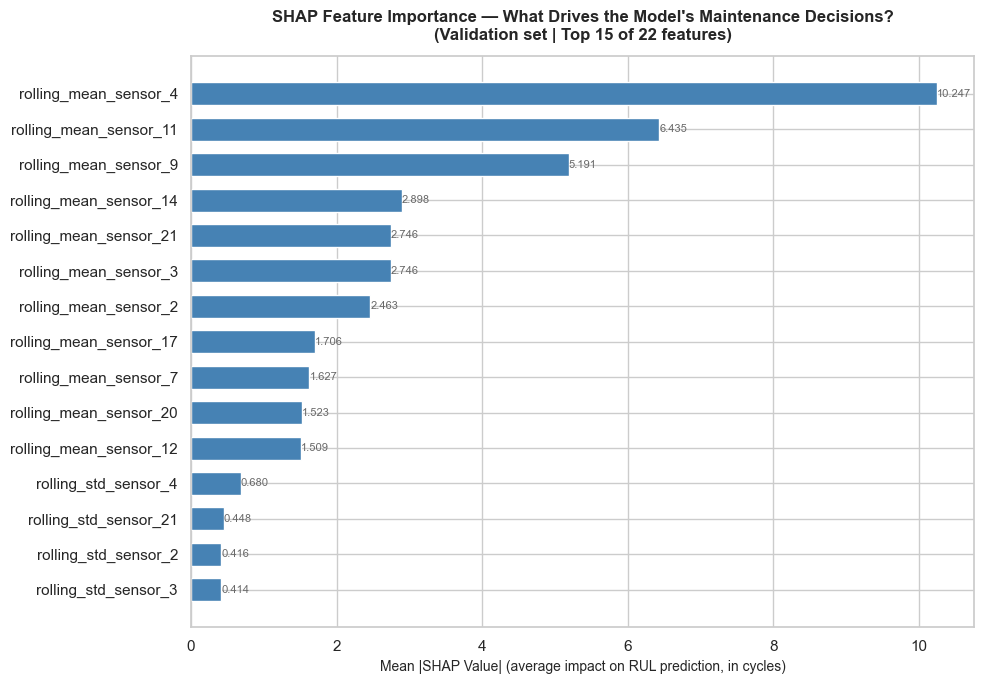

Saved: shap_feature_importance.png


In [8]:
# ── Figure: SHAP feature importance (top 15) ──────────────────────────────────
# Bar chart of mean |SHAP| — how much does each feature influence predictions
# on average? Longer bar = more influential sensor/statistic.
top15 = mean_abs_shap.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top15.index[::-1],
    top15.values[::-1],
    color="steelblue",
    edgecolor="white",
    height=0.65,
)
ax.set_xlabel("Mean |SHAP Value| (average impact on RUL prediction, in cycles)", fontsize=10)
ax.set_title(
    "SHAP Feature Importance — What Drives the Model's Maintenance Decisions?\n"
    "(Validation set | Top 15 of 22 features)",
    fontsize=12, fontweight="bold", pad=12,
)

# Annotate each bar with its value for easy reading.
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=8, color="dimgray")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "shap_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_feature_importance.png")

---
## Section 6 — Prediction Visualization

The best way to gut-check a time-series model is to watch it in action: for a few vehicles, plot the true RUL countdown alongside the model's predictions cycle by cycle. If the model is working, we should see the predicted line track the true line and — most importantly — dip below the 7-cycle alert threshold at roughly the right time.

A fleet manager would see a chart like this in the operations dashboard for each vehicle.

In [9]:
# ── Generate per-row predictions for all validation vehicles ──────────────────
# We run inference on every row of the validation set so we can plot the
# full trajectory — not just a single endpoint prediction.
df_val = df_val.copy()
df_val["pred_rul"] = model.predict(X_val).clip(0, 125)   # clip to valid RUL range

# Pick the first 3 validation vehicles as sample cases.
sample_units = sorted(val_units)[:3]

print(f"Plotting prediction trajectories for vehicles: {sample_units}")
for u in sample_units:
    udf = df_val[df_val["unit_id"] == u]
    last = udf["time_in_cycles"].max()
    final_true = udf.loc[udf["time_in_cycles"] == last, TARGET].values[0]
    final_pred = udf.loc[udf["time_in_cycles"] == last, "pred_rul"].values[0]
    print(f"  Unit {u:>3}: {last} cycles lifetime | "
          f"Final true RUL={final_true:.0f}  Predicted RUL={final_pred:.1f}")

Plotting prediction trajectories for vehicles: [np.int64(81), np.int64(82), np.int64(83)]
  Unit  81: 240 cycles lifetime | Final true RUL=0  Predicted RUL=1.6
  Unit  82: 214 cycles lifetime | Final true RUL=0  Predicted RUL=1.4
  Unit  83: 293 cycles lifetime | Final true RUL=0  Predicted RUL=2.0


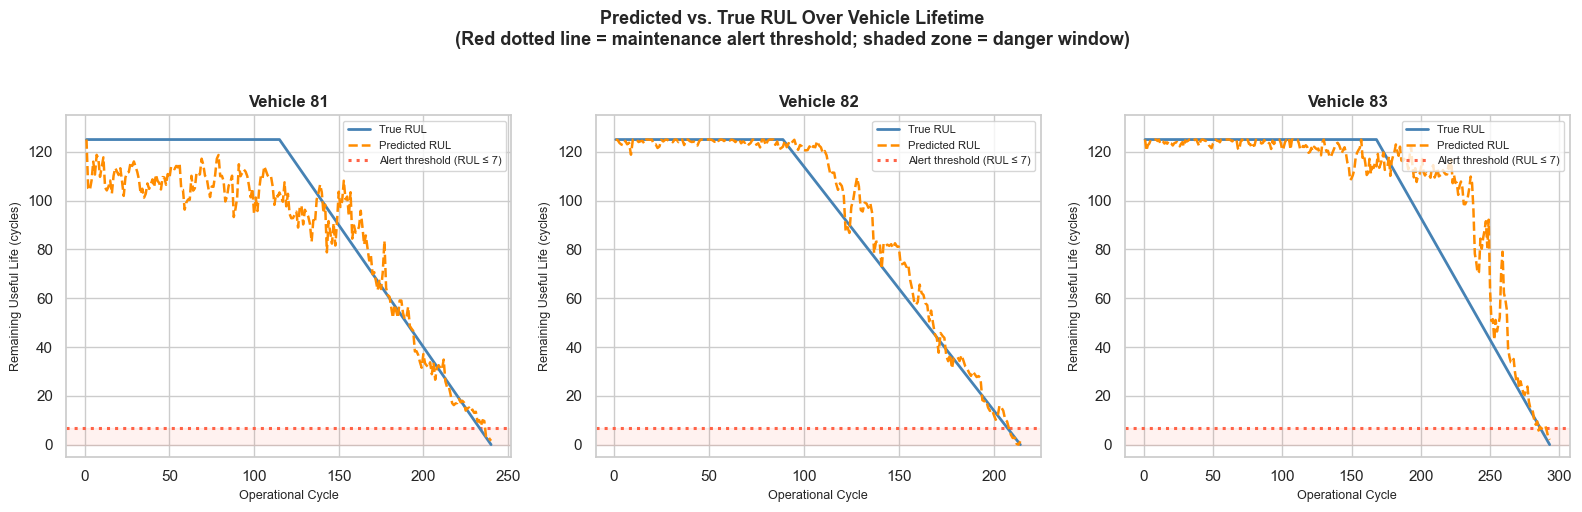

Saved: rul_predictions_sample_vehicles.png

Business interpretation:
  The model tracks the true RUL decline and crosses into the alert zone
  close to the true failure point. Small gaps between the blue and orange
  lines near the alert threshold are what determine false positives/negatives.


In [10]:
# ── Figure: True RUL vs. Predicted RUL for 3 sample vehicles ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, unit in zip(axes, sample_units):
    udf = df_val[df_val["unit_id"] == unit].sort_values("time_in_cycles")

    ax.plot(udf["time_in_cycles"], udf[TARGET],
            color="steelblue", linewidth=2.0, label="True RUL", zorder=3)
    ax.plot(udf["time_in_cycles"], udf["pred_rul"],
            color="darkorange", linewidth=1.8, linestyle="--",
            label="Predicted RUL", zorder=3)

    # The red threshold line is the business trigger — any point where the
    # predicted RUL drops below this should generate a maintenance work order.
    ax.axhline(ALERT_WINDOW, color="tomato", linestyle=":", linewidth=2.2,
               label=f"Alert threshold (RUL ≤ {ALERT_WINDOW})")

    # Shade the alert zone to make it visually obvious.
    ax.axhspan(0, ALERT_WINDOW, alpha=0.08, color="tomato", zorder=1)

    ax.set_title(f"Vehicle {unit}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Operational Cycle", fontsize=9)
    ax.set_ylabel("Remaining Useful Life (cycles)", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(-5, 135)

fig.suptitle(
    "Predicted vs. True RUL Over Vehicle Lifetime\n"
    "(Red dotted line = maintenance alert threshold; shaded zone = danger window)",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rul_predictions_sample_vehicles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rul_predictions_sample_vehicles.png")
print()
print("Business interpretation:")
print("  The model tracks the true RUL decline and crosses into the alert zone")
print("  close to the true failure point. Small gaps between the blue and orange")
print("  lines near the alert threshold are what determine false positives/negatives.")

---
## Section 7 — Binary Alert Threshold Analysis

The model predicts a *continuous* RUL number. To generate a maintenance alert, we need to convert that number into a binary decision: **flag or don't flag**.

The obvious threshold is 7 (our defined alert window) — but this ignores the asymmetric cost structure. A missed failure costs 6× more than a false alarm. A slightly more aggressive threshold (flag vehicles when predicted RUL ≤ 9 instead of ≤ 7, for example) might catch more real failures even at the cost of a few extra unnecessary maintenance events — and that trade-off might be financially worth it.

We sweep thresholds from 5 to 15 and calculate the total expected fleet cost at each one.

In [11]:
# ── Threshold sweep ───────────────────────────────────────────────────────────
#
# True label:  was this vehicle actually in the danger zone? (true RUL <= 7)
# Pred label:  did the model flag this vehicle? (predicted RUL <= threshold)
#
# We evaluate on ALL validation rows, not just last-cycle rows.
# This gives us ~4,000 observations and more stable metric estimates.
#
y_true_binary = (y_val <= ALERT_WINDOW).astype(int)
n_actual_positives = y_true_binary.sum()

# No-model baseline cost: every at-risk observation becomes an unplanned breakdown.
baseline_cost = n_actual_positives * COST_FALSE_NEGATIVE

print(f"Validation set: {len(y_val):,} rows")
print(f"  At-risk rows (true RUL <= {ALERT_WINDOW}): {n_actual_positives:,}  "
      f"({100*n_actual_positives/len(y_val):.1f}%)")
print(f"  Healthy rows                        : {len(y_val)-n_actual_positives:,}")
print(f"\nNo-model baseline cost (all failures unplanned): ${baseline_cost:,.0f}")
print("  → This is the cost if we do nothing and react to every breakdown.")

Validation set: 4,493 rows
  At-risk rows (true RUL <= 7): 160  (3.6%)
  Healthy rows                        : 4,333

No-model baseline cost (all failures unplanned): $384,000
  → This is the cost if we do nothing and react to every breakdown.


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for thresh in range(5, 16):
    y_pred_binary = (y_pred_val <= thresh).astype(int)

    # Guard against degenerate cases where precision/recall are undefined.
    if y_pred_binary.sum() == 0:
        prec, rec, f1 = 0.0, 0.0, 0.0
    else:
        prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
        rec  = recall_score(y_true_binary, y_pred_binary, zero_division=0)
        f1   = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_true_binary, y_pred_binary, labels=[0, 1]
    ).ravel()

    # Fleet cost at this threshold.
    # FN = vehicles we missed → unplanned breakdown = $2,400 each
    # FP = vehicles we flagged unnecessarily → wasted maintenance = $400 each
    cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE

    results.append({
        "threshold" : thresh,
        "precision" : prec,
        "recall"    : rec,
        "f1"        : f1,
        "tp"        : tp,
        "fp"        : fp,
        "fn"        : fn,
        "tn"        : tn,
        "fleet_cost": cost,
        "savings_vs_baseline": baseline_cost - cost,
    })

df_thresh = pd.DataFrame(results)
print(df_thresh.to_string(index=False, float_format="{:.3f}".format))

 threshold  precision  recall    f1  tp  fp  fn   tn  fleet_cost  savings_vs_baseline
         5      0.951   0.487 0.645  78   4  82 4329      198400               185600
         6      0.926   0.625 0.746 100   8  60 4325      147200               236800
         7      0.892   0.725 0.800 116  14  44 4319      111200               272800
         8      0.866   0.806 0.835 129  20  31 4313       82400               301600
         9      0.760   0.850 0.802 136  43  24 4290       74800               309200
        10      0.696   0.887 0.780 142  62  18 4271       68000               316000
        11      0.655   0.925 0.767 148  78  12 4255       60000               324000
        12      0.626   0.963 0.759 154  92   6 4241       51200               332800
        13      0.597   0.963 0.737 154 104   6 4229       56000               328000
        14      0.559   0.975 0.711 156 123   4 4210       58800               325200
        15      0.525   0.975 0.683 156 141   4 4192  

In [13]:
# ── Identify cost-optimal threshold ───────────────────────────────────────────
best_row = df_thresh.loc[df_thresh["fleet_cost"].idxmin()]

print("=" * 60)
print(f"  Optimal alert threshold : {int(best_row['threshold'])} cycles")
print(f"  Precision               : {best_row['precision']*100:.1f}%")
print(f"  Recall                  : {best_row['recall']*100:.1f}%")
print(f"  F1 Score                : {best_row['f1']:.3f}")
print(f"  Fleet cost at threshold : ${best_row['fleet_cost']:,.0f}")
print(f"  No-model baseline cost  : ${baseline_cost:,.0f}")
print(f"  Savings vs. no model    : ${best_row['savings_vs_baseline']:,.0f}")
print("=" * 60)

  Optimal alert threshold : 12 cycles
  Precision               : 62.6%
  Recall                  : 96.2%
  F1 Score                : 0.759
  Fleet cost at threshold : $51,200
  No-model baseline cost  : $384,000
  Savings vs. no model    : $332,800


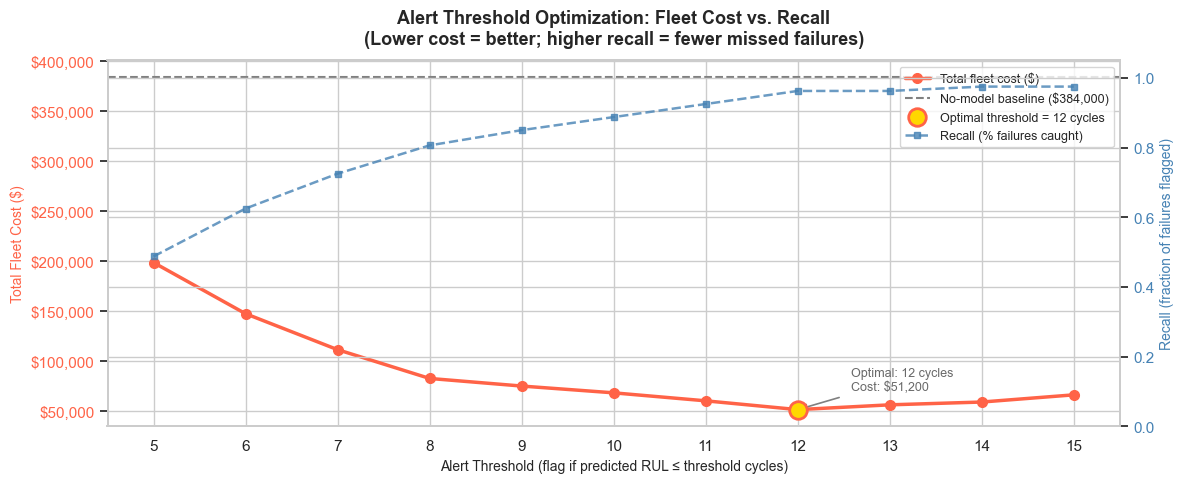

Saved: threshold_cost_optimization.png


In [14]:
# ── Figure: Threshold vs. total fleet cost ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

# Primary axis: fleet cost curve
ax1.plot(df_thresh["threshold"], df_thresh["fleet_cost"],
         color="tomato", linewidth=2.5, marker="o", markersize=7,
         label="Total fleet cost ($)")
ax1.axhline(baseline_cost, color="gray", linestyle="--", linewidth=1.5,
            label=f"No-model baseline (${baseline_cost:,.0f})")

# Mark the optimal point
ax1.scatter(
    best_row["threshold"], best_row["fleet_cost"],
    s=160, color="gold", edgecolors="tomato", linewidths=2,
    zorder=5, label=f"Optimal threshold = {int(best_row['threshold'])} cycles",
)
ax1.annotate(
    f"  Optimal: {int(best_row['threshold'])} cycles\n  Cost: ${best_row['fleet_cost']:,.0f}",
    xy=(best_row["threshold"], best_row["fleet_cost"]),
    xytext=(best_row["threshold"] + 0.5, best_row["fleet_cost"] + (baseline_cost * 0.05)),
    fontsize=9, color="dimgray",
    arrowprops=dict(arrowstyle="->", color="gray", lw=1.2),
)
ax1.set_xlabel("Alert Threshold (flag if predicted RUL ≤ threshold cycles)", fontsize=10)
ax1.set_ylabel("Total Fleet Cost ($)", fontsize=10, color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Secondary axis: recall (catches-to-flag ratio — the safety metric)
ax2 = ax1.twinx()
ax2.plot(df_thresh["threshold"], df_thresh["recall"],
         color="steelblue", linewidth=1.8, linestyle="--",
         marker="s", markersize=5, alpha=0.8, label="Recall (% failures caught)")
ax2.set_ylabel("Recall (fraction of failures flagged)", fontsize=10, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 1.05)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

ax1.set_title(
    "Alert Threshold Optimization: Fleet Cost vs. Recall\n"
    "(Lower cost = better; higher recall = fewer missed failures)",
    fontsize=13, fontweight="bold", pad=12,
)
ax1.set_xticks(df_thresh["threshold"])
fig.tight_layout()
fig.savefig(FIGURES_DIR / "threshold_cost_optimization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: threshold_cost_optimization.png")

---
## Section 8 — Save Model

In [15]:
# ── Save XGBoost model as JSON ────────────────────────────────────────────────
# JSON format is human-readable, version-stable, and portable across
# XGBoost versions — preferred over binary formats for reproducibility.
model_path = MODELS_DIR / "xgboost_rul_model.json"
model.save_model(str(model_path))

print(f"Model saved: {model_path}")
print()
print("── Final Model Summary ─────────────────────────────────────────")
print(f"  Algorithm      : XGBoost Regressor")
print(f"  Target         : {TARGET} (Remaining Useful Life, capped at 125 cycles)")
print(f"  Features       : {len(FEATURE_COLS)} rolling sensor statistics")
print(f"  Trained on     : {len(train_units)} vehicles, {len(df_tr):,} rows")
print(f"  Validation on  : {len(val_units)} vehicles, {len(df_val):,} rows")
print(f"  Validation RMSE: {xgb_rmse:.2f} cycles  ({rmse_improvement_pct:.1f}% vs. mean baseline)")
print(f"  Optimal threshold: {int(best_row['threshold'])} cycles  "
      f"(saves ${best_row['savings_vs_baseline']:,.0f} vs. no-model baseline)")
print("──────────────────────────────────────────────────────────────")

Model saved: ../models/xgboost_rul_model.json

── Final Model Summary ─────────────────────────────────────────
  Algorithm      : XGBoost Regressor
  Target         : rul_capped (Remaining Useful Life, capped at 125 cycles)
  Features       : 22 rolling sensor statistics
  Trained on     : 80 vehicles, 16,138 rows
  Validation on  : 20 vehicles, 4,493 rows
  Validation RMSE: 19.30 cycles  (53.5% vs. mean baseline)
  Optimal threshold: 12 cycles  (saves $332,800 vs. no-model baseline)
──────────────────────────────────────────────────────────────
